# ZEPTAT SE PEPY
- jaky je problem s Batchnorm

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import torch

In [44]:
import sys, os
sys.path.append(os.path.abspath(".."))
from src.plotting_styles import apply_global_style

In [71]:
from src.load_sam_data import load_dataset

dataset = load_dataset("FJ")
dataset = np.array(dataset)

..\data\FJ\FI01X1\FI01X1_ch


In [82]:
from src.load_sam_data import load_dataset

dataset = load_dataset("FJ")
full_dataset = np.array(dataset)

zero_pts = []
for idx, data in enumerate(full_dataset):
    if data.any() == np.zeros(96).any(): 
        zero_pts.append(idx)

dataset_no_outs = np.delete(full_dataset, zero_pts, axis=0)

..\data\FJ\FI01X1\FI01X1_ch


In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(dataset_no_outs, shuffle=True, train_size=0.8, random_state=42)

In [ ]:
# prepsat preprocess data
from src.autoencoders import prepocess_data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train, ax)  
X_test = scaler.transform(X_test) 
X_full_scaled = scaler.transform(full_dataset)

dataset_no_outs = torch.from_numpy(dataset_no_outs)
X_train = torch.from_numpy(X_train)
X_test = torch.from_numpy(X_test)
X_full_scaled = scaler.transform(full_dataset)

dataset_no_outs = dataset_no_outs.to(torch.float32)
X_train = X_train.to(torch.float32)
X_test = X_test.to(torch.float32)
X_full_scaled = scaler.transform(full_dataset)

<BarContainer object of 96 artists>

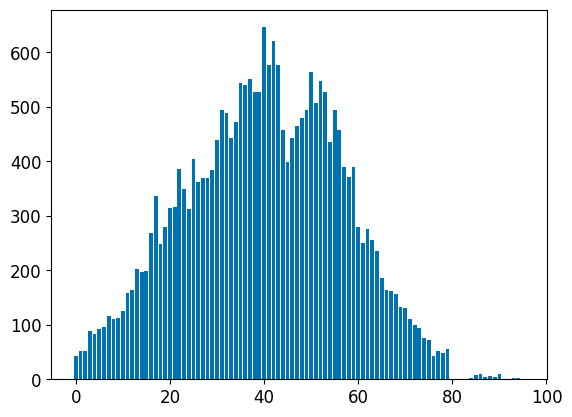

In [86]:
idx = 0
plt.bar(range(len(full_dataset[idx])), full_dataset[idx])

<BarContainer object of 96 artists>

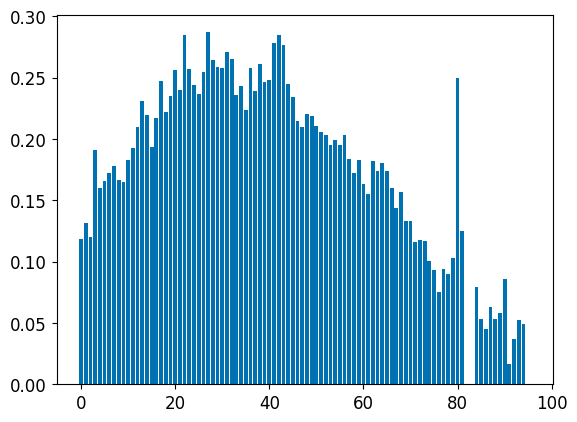

In [74]:
idx = 0
plt.bar(range(len(dataset[idx])), dataset[idx])

In [49]:
import torch.nn as nn

# first model
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(96, 64),  
            nn.ReLU(),

            nn.Linear(64, 32),  
            nn.ReLU(),
            
            nn.Linear(32, 16),  
            nn.Sigmoid(),
            )

        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            
            nn.Linear(32, 64),
            nn.ReLU(),

            nn.Linear(64, 96),
            nn.Sigmoid()
            )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [50]:
from torch.utils.data import Dataset, DataLoader

class HistDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        x = self.df[idx]

        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        
        x = x.unsqueeze(0)
        return x

In [51]:
batch_size = 32
torch_small_df = HistDataset(dataset)
dataloader = DataLoader(torch_small_df, batch_size=batch_size, shuffle=False)

ae_conv = Autoencoder()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(params=ae_conv.parameters(), lr=0.001)

In [52]:
batch = next(iter(dataloader))

# Ak dataloader vracia dvojicu (X, y)
data = batch 
print(data.shape)

torch.Size([32, 1, 96])


In [53]:
from src.autoencoders import train_ae

ae_conv.train()
losses, ae_conv = train_ae(n_epochs=40, dataloader=dataloader, model=ae_conv, optimizer=optimizer, criterion=criterion)

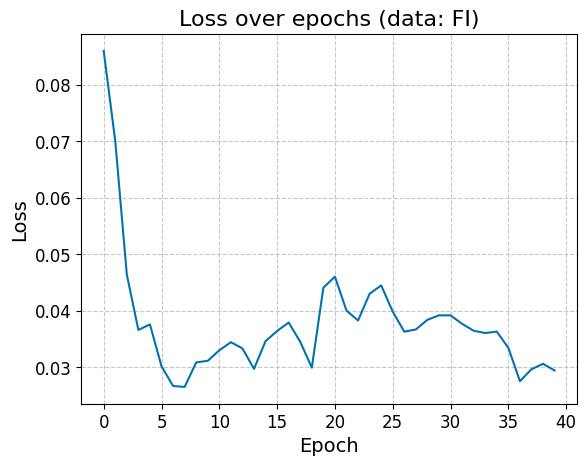

In [54]:
apply_global_style()
plt.title("Loss over epochs (data: FI)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(range(len(losses)), losses)
plt.show()

c:\Users\hrdyj\coding\vyzkumak\mlenv\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([1, 96])) that is different to the input size (torch.Size([1, 1, 96])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


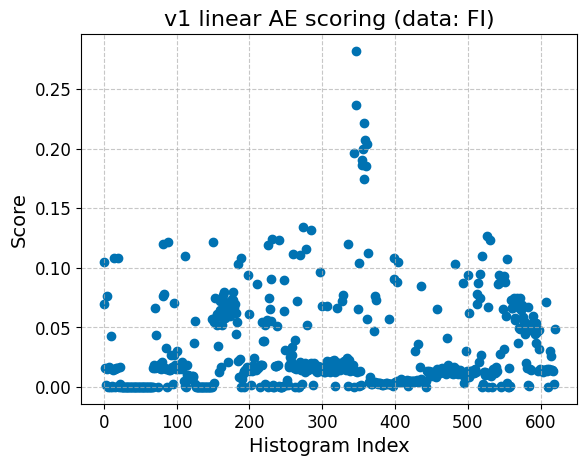

In [55]:
from src.autoencoders import eval_and_plot_score
apply_global_style()
plt.title("v1 linear AE scoring (data: FI)")
plt.xlabel("Histogram Index")
plt.ylabel("Score")
score = eval_and_plot_score(model=ae_conv, dataloader=dataloader, criterion=criterion)

Locating outliers same as kNN and OCSVM but not discovering point 363 (which may or may not be considered)

In [56]:
outliers = np.where(np.array(score) > 0.15)
outliers

(array([343, 346, 347, 354, 355, 356, 357, 358, 359, 360, 361]),)

In [57]:
dataset[5]

tensor([0.1381, 0.1186, 0.1315, 0.1413, 0.1768, 0.1387, 0.1649, 0.1626, 0.1744,
        0.1603, 0.1942, 0.1841, 0.2262, 0.1822, 0.2209, 0.2245, 0.1987, 0.2190,
        0.2084, 0.2175, 0.2041, 0.2179, 0.2153, 0.2804, 0.2179, 0.2201, 0.2270,
        0.2488, 0.2652, 0.2535, 0.2370, 0.2504, 0.2372, 0.2172, 0.2288, 0.2247,
        0.2315, 0.2143, 0.2192, 0.2207, 0.2471, 0.2452, 0.2584, 0.2505, 0.2353,
        0.2456, 0.1948, 0.1963, 0.1944, 0.2017, 0.1857, 0.1903, 0.1908, 0.1665,
        0.1756, 0.1571, 0.1593, 0.1748, 0.1636, 0.1676, 0.1484, 0.1448, 0.1609,
        0.1810, 0.1557, 0.1325, 0.1378, 0.1374, 0.1229, 0.1607, 0.1320, 0.1109,
        0.1120, 0.1104, 0.0792, 0.0983, 0.0838, 0.0701, 0.0902, 0.0956, 0.2500,
        0.0000, 0.0000, 0.0000, 0.0263, 0.0840, 0.0300, 0.0506, 0.0536, 0.0290,
        0.0513, 0.0667, 0.0741, 0.0263, 0.1463, 0.1739])

In [58]:
preds = list()

with torch.no_grad():
    for idx, data in enumerate(dataset):
        pred = ae_conv(data).numpy()
         
        for p in preds:
            if (pred == p).all():
                break
        else:
            preds.append(pred)

In [59]:
len(preds)

77

In [60]:
dataset[15]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

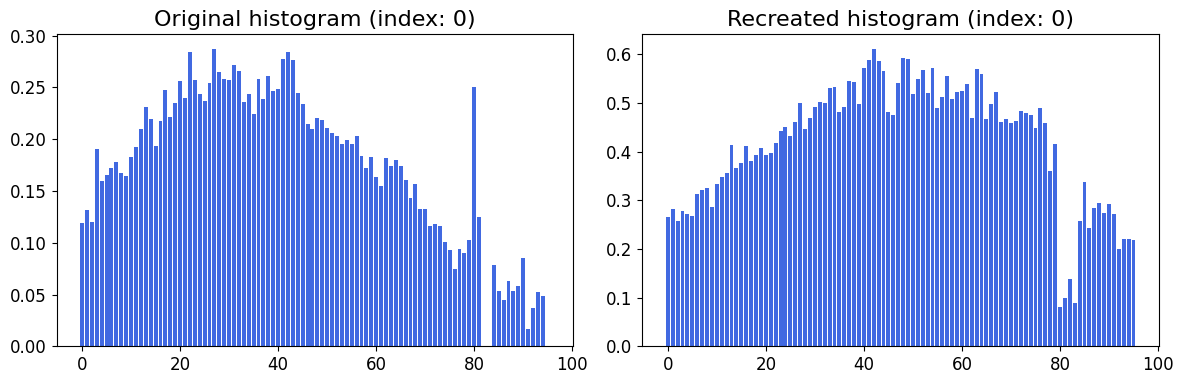

In [69]:
idx = 0

ae_conv.eval()
pred = ae_conv(dataset[idx]).detach().numpy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(pred)), dataset[idx], zorder=1, color='royalblue')
axes[0].set_title(f"Original histogram (index: {idx})")
#axes[0].grid(True, linestyle='--', alpha=0.7, zorder=-2)

axes[1].bar(range(len(pred)), pred, zorder=1, color='royalblue')
axes[1].set_title(f"Recreated histogram (index: {idx})")
#axes[1].grid(True, linestyle='--', alpha=0.7, zorder=-2)

plt.tight_layout()
plt.show()

In [62]:
score_dict = {idx : s for idx, s in enumerate(score)}
indexes_sorted_by_score = sorted(score_dict, key=lambda x: score_dict[x], reverse=True)

print("highest scores", indexes_sorted_by_score[:10] )
print("lowest scores", indexes_sorted_by_score[-3:])

highest scores [346, 347, 357, 359, 361, 356, 343, 355, 354, 360]
lowest scores [268, 533, 546]


In [63]:
bad_pred = ae_conv(dataset[15]).detach().numpy()

bad_indexes = []
ae_conv.eval()
for idx, pt in enumerate(dataset):
    if ae_conv(pt).detach().numpy().all() == bad_pred.all():
        bad_indexes.append(idx)
bad_indexes

[6,
 8,
 11,
 12,
 15,
 20,
 21,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 75,
 87,
 112,
 113,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 188,
 192,
 214,
 225,
 233,
 234,
 241,
 242,
 243,
 244,
 245,
 246,
 263,
 267,
 268,
 317,
 336,
 344,
 351,
 397,
 418,
 443,
 520,
 527,
 533,
 545,
 546,
 555,
 556,
 558,
 584,
 610]

In [64]:
bad_indexes[80:]

[225,
 233,
 234,
 241,
 242,
 243,
 244,
 245,
 246,
 263,
 267,
 268,
 317,
 336,
 344,
 351,
 397,
 418,
 443,
 520,
 527,
 533,
 545,
 546,
 555,
 556,
 558,
 584,
 610]

In [65]:
len(bad_indexes)

109

C:\Users\hrdyj\AppData\Local\Temp\ipykernel_51708\1895499744.py:21: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axes[i].set_ylim(0, max(data) * 1.1) # Dynamický limit Y osi s rezervou


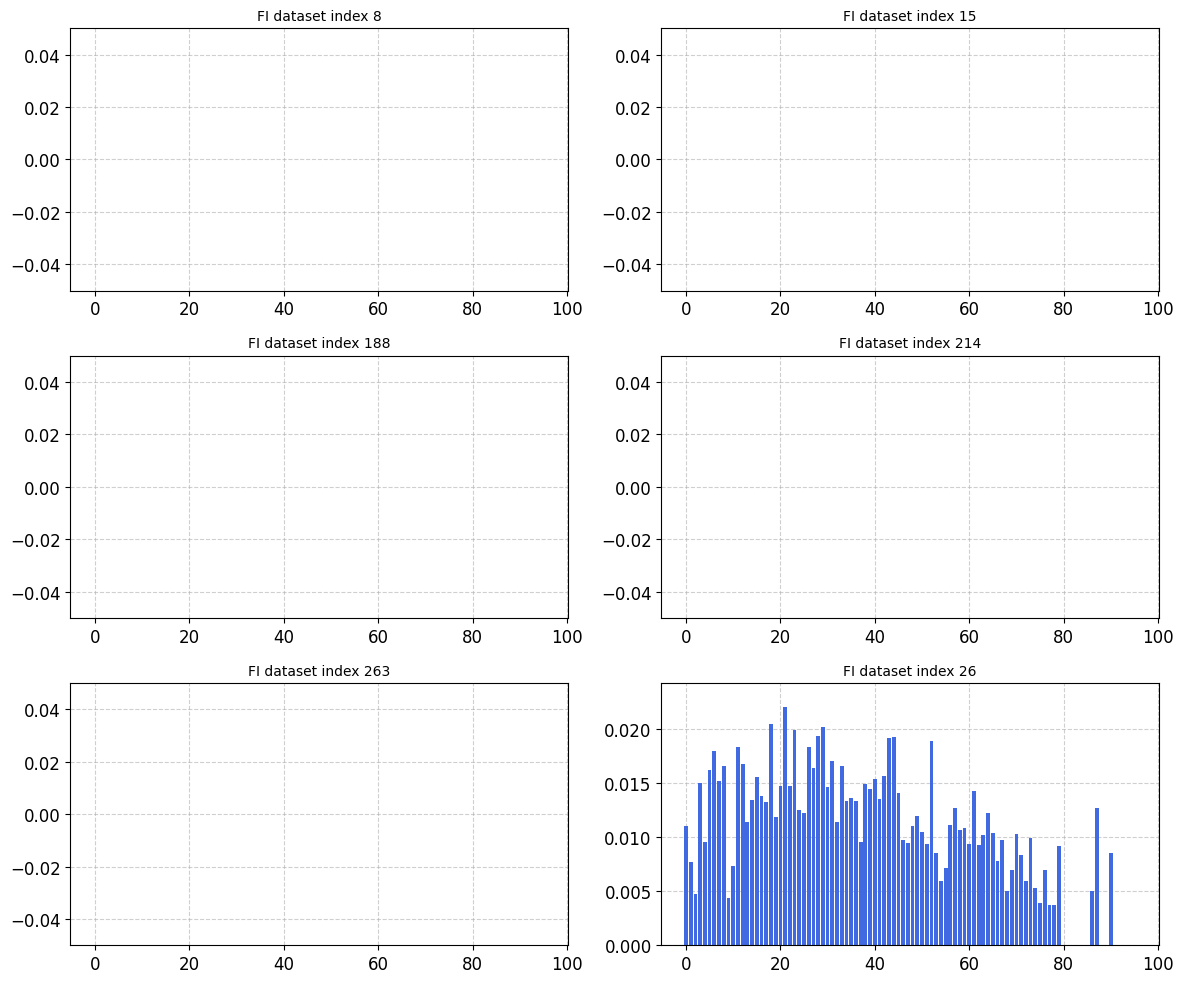

In [66]:
import matplotlib.pyplot as plt

# Zoznam indexov na vykreslenie
indices = [8, 15, 188, 214, 263, 26]

# Vytvorenie mriežky 3 riadky x 2 stĺpce
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten() # Sploštenie poľa osí pre jednoduchšiu iteráciu

for i, idx in enumerate(indices):
    # Výber dát z datasetu
    # Používame .flatten(), aby sme mali 1D pole pre bar plot
    data = dataset[idx].flatten().detach().numpy() if hasattr(dataset[idx], 'detach') else dataset[idx].flatten()
    
    # Vykreslenie bar plotu
    axes[i].bar(range(len(data)), data, color='royalblue', zorder=2)
    
    # Formátovanie
    axes[i].set_title(f"FI dataset index {idx}", fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.6, zorder=1)
    axes[i].set_ylim(0, max(data) * 1.1) # Dynamický limit Y osi s rezervou

plt.tight_layout()
plt.show()

In [67]:
np.zeros(96).any() == dataset[15].any()

tensor(True)

In [68]:
zero_pts = []
for idx, data in enumerate(dataset):
    if data.numpy().any() == np.zeros(96).any(): 
        zero_pts.append(idx)
zero_pts

[8, 15, 188, 214, 263, 268, 533, 546]